In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

listings = pd.read_csv("../data/processed/listings_clean.csv",
                       parse_dates=['host_since', 'first_review', 'last_review'])

print("Loaded shape:", listings.shape)

Loaded shape: (44304, 56)


In [3]:
SCRAPE_DATE = pd.Timestamp("2025-07-04")

# How many days the host has been active on Airbnb
listings['host_tenure_days'] = (SCRAPE_DATE - listings['host_since']).dt.days

# How recently the listing got a review
# Listings with zero reviews have NaT in last_review — use a large sentinel
listings['review_recency_days'] = (SCRAPE_DATE - listings['last_review']).dt.days
listings['review_recency_days'] = listings['review_recency_days'].fillna(9999)

# Drop the raw date columns — everything useful is now numeric
listings = listings.drop(columns=['host_since', 'first_review', 'last_review'])

print(listings[['host_tenure_days', 'review_recency_days']].describe())

       host_tenure_days  review_recency_days
count      44304.000000         44304.000000
mean        2634.406306          1200.000158
std         1177.583095          3067.407442
min            2.000000            -8.000000
25%         1951.000000            18.000000
50%         2886.000000            71.000000
75%         3436.000000           182.000000
max         5814.000000          9999.000000


In [4]:
# host_response_time is categorical — NaN means host has no response record
# Fill with "unknown" so it becomes a valid category for encoding later
listings['host_response_time'] = listings['host_response_time'].fillna('unknown')

# host_response_rate and host_acceptance_rate — treat no record as 0
listings['host_response_rate']   = listings['host_response_rate'].fillna(0)
listings['host_acceptance_rate'] = listings['host_acceptance_rate'].fillna(0)

# Confirm no more nulls in these columns
print(listings[['host_response_time', 'host_response_rate',
                'host_acceptance_rate']].isnull().sum())

host_response_time      0
host_response_rate      0
host_acceptance_rate    0
dtype: int64


In [5]:
# See what we're working with — long tail expected
print(listings['property_type'].value_counts().head(20))

property_type
Entire home                          17455
Entire rental unit                    6158
Private room in home                  4051
Entire guesthouse                     3150
Entire guest suite                    2376
Entire cottage                        1215
Private room in bed and breakfast      872
Entire townhouse                       863
Entire cabin                           818
Tiny home                              620
Farm stay                              558
Entire villa                           498
Room in hotel                          497
Entire bungalow                        488
Private room in guest suite            430
Private room in rental unit            385
Entire serviced apartment              339
Entire condo                           298
Entire vacation home                   292
Private room in farm stay              234
Name: count, dtype: int64


In [6]:
def group_property_type(pt):
    pt = str(pt).lower()
    if 'entire' in pt:
        return 'Entire home/apt'
    elif 'private room' in pt:
        return 'Private room'
    elif 'shared room' in pt:
        return 'Shared room'
    elif any(word in pt for word in ['hotel', 'boutique', 'hostel', 'motel', 'resort']):
        return 'Hotel/Boutique'
    else:
        return 'Unique/Other'

listings['property_type_grouped'] = listings['property_type'].apply(group_property_type)

# Verify distribution
print(listings['property_type_grouped'].value_counts())

property_type_grouped
Entire home/apt    34382
Private room        7221
Unique/Other        1873
Hotel/Boutique       705
Shared room          123
Name: count, dtype: int64


In [7]:
cols_to_drop = [
    'id',                   # listing identifier, not predictive
    'host_location',        # 21% missing free text, not useful
    'bathrooms_text',       # replaced by bathrooms_num
    'bathrooms',            # replaced by bathrooms_num
    'property_type',        # replaced by property_type_grouped
]

# Only drop columns that actually exist (guards against double-running)
cols_to_drop = [c for c in cols_to_drop if c in listings.columns]
listings = listings.drop(columns=cols_to_drop)

print("Shape after dropping columns:", listings.shape)
print("Remaining columns:\n", listings.columns.tolist())

Shape after dropping columns: (44304, 51)
Remaining columns:
 ['host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_listings_count', 'host_total_listings_count', 'host_has_profile_pic', 'host_identity_verified', 'latitude', 'longitude', 'room_type', 'accommodates', 'bedrooms', 'beds', 'price', 'minimum_nights', 'maximum_nights', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'availability_eoy', 'number_of_reviews_ly', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'instant_bookable', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms', 'region_id', 'region_name', 'regio

In [8]:
corr = listings.corr(numeric_only=True)['price'].sort_values(ascending=False)

print("=== Top 10 positive correlators with price ===")
print(corr.head(10))

print("\n=== Bottom 10 (most negative) correlators with price ===")
print(corr.tail(10))

=== Top 10 positive correlators with price ===
price                                          1.000000
bedrooms                                       0.556382
accommodates                                   0.554850
bathrooms_num                                  0.538937
beds                                           0.438990
amenities_count                                0.156132
calculated_host_listings_count_entire_homes    0.095102
calculated_host_listings_count                 0.094018
review_recency_days                            0.093955
host_listings_count                            0.093468
Name: price, dtype: float64

=== Bottom 10 (most negative) correlators with price ===
has_reviews                   -0.085226
review_scores_communication   -0.086728
review_scores_value           -0.099288
latitude                      -0.128473
number_of_reviews_l30d        -0.137186
number_of_reviews             -0.172845
number_of_reviews_ly          -0.179530
number_of_reviews_ltm      

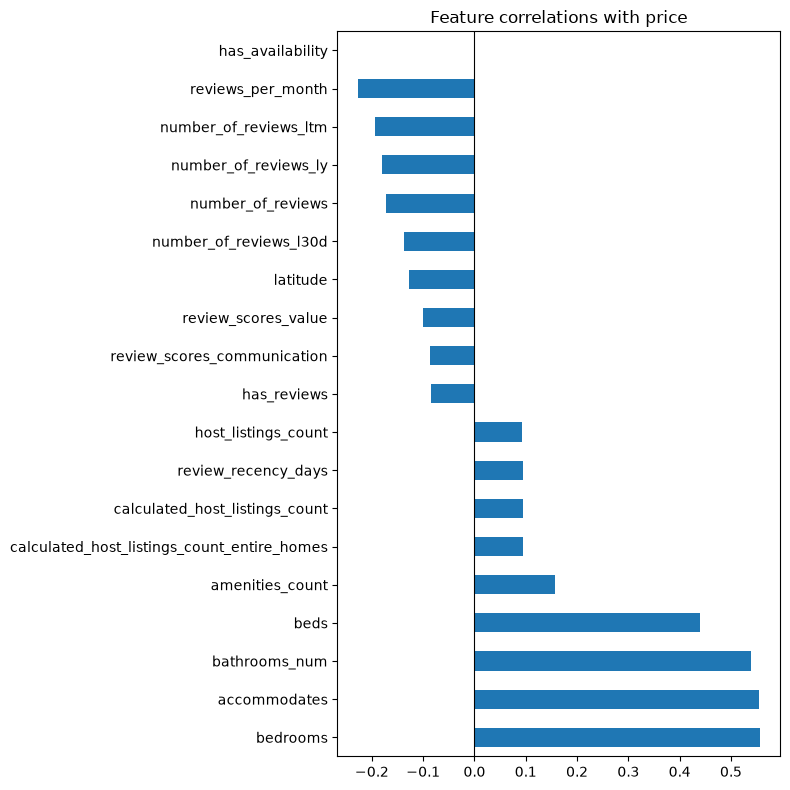

In [9]:
# Bar chart for a visual read
top_corr = pd.concat([corr.head(10), corr.tail(10)])
top_corr.drop('price', errors='ignore').plot(kind='barh', figsize=(8, 8))
plt.title("Feature correlations with price")
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [10]:
os.makedirs('../data/processed', exist_ok=True)
listings.to_csv('../data/processed/listings_features.csv', index=False)

print("Saved. Final shape:", listings.shape)

Saved. Final shape: (44304, 51)
